# 深層学習を用いた言語モデル

深層学習を用いてマルコフモデルを実装し、言語モデリングにおける深層学習の活用方法を学ぶ。

In [ ]:
import random

from datasets import load_from_disk
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import wandb
from environs import env
from tqdm import tqdm
import matplotlib.pyplot as plt

wandb.login(key=env.str("WANDB_API_KEY"))
device = torch.accelerator.current_accelerator()

深層学習を活用することで、より高度な文章生成が可能な言語モデルを作ることができる。近年話題のLLMは全て深層学習によって作られている。

深層学習を活用すると可変長の文脈を考慮できるモデルを作ることが出来るが、本章ではそれを行わない。前章で作成したマルコフモデルの様な「固定長の文脈（直前のトークン）から次の単語を予測するモデル」をニューラルネットワークを用いて作成する。まずは深層学習を用いて言語モデル実装を行うための基礎的な手法を学ぶ。


---

## 学習データの用意

ニューラルネットに与えられる形式で学習データを整える。

前章で作成したデータとトークナイザを読み込む。

In [47]:
from transformers import PreTrainedTokenizerFast
from datasets import load_from_disk

tokenizer = PreTrainedTokenizerFast(tokenizer_file="trained/tokenizer/jawiki.json")
tokenizer.add_special_tokens({
    "unk_token": "<unk>",
    "bos_token": "<s>",
    "eos_token": "</s>",
    "pad_token": "<pad>",
})
ds = load_from_disk("data/jawiki")["train"]
ds

Loading dataset from disk:   0%|          | 0/19 [00:00<?, ?it/s]

Dataset({
    features: ['meta', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1363395
})

本章ではこんなにいらないので減らしておく。

In [4]:
ds = ds.shuffle().select(range(int(len(ds) * 0.1)))
ds

Dataset({
    features: ['meta', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 136339
})

評価用データも用意しておく。

In [5]:
ds = ds.train_test_split(test_size=0.05)
ds_train, ds_test = ds["train"], ds["test"]

PyTorchで扱えるデータセットを作成する。今回は直前の単語から次の単語を予測するモデルを作成するため、各サンプルは直前の単語と次の単語のペアとなる。

In [6]:
from torch.utils.data import Dataset, DataLoader

class TextDataset(Dataset):
    def __init__(self, ids):
        self.x = [] # 入力
        self.label = [] # 正解
        for ids_ in ids:
            self.x += ids_[:-1] # 単語
            self.label += ids_[1:] # 次の単語
        self.n_data = len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.label[idx]
    def __len__(self):
        return self.n_data

# Dataset作成
dataset_train = TextDataset(ds_test["input_ids"])
dataset_test = TextDataset(ds_test["input_ids"])

# DataLoader作成
batch_size = 1024
train_loader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset_test, batch_size=batch_size)

# examples
x, label = next(iter(train_loader))
x, label

(tensor([ 954,  225, 1792,  ...,   29,    7, 3195]),
 tensor([381, 654, 450,  ...,  16, 167, 180]))


---

## モデル構築

ある単語から次の単語を予測するNNを作る。クラスラベルの入力に向け、埋め込み層を取り入れる。

### 埋め込み層

*Embedding Layer*

指定したIDに対応するベクトルを出力する層。言語モデルとなるNNを構築する際に良く用いられる層。

単語IDはクラスラベルなので、そのままNNに入力するのは適切ではない。そこで、埋め込み層と呼ばれる層を用いて単語IDを指定した次元のベクトルに変換する。単語をベクトル化することは埋め込みと呼ばれるので、埋め込み層と呼ばれる。

埋め込み層は語彙の数だけベクトルを持っている。IDが入力されると、対応するベクトルが出力される。実装してみよう。

In [7]:
class Embedding(nn.Module):
    def __init__(self, n_vocab: int, embed_dim: int):
        super().__init__()
        self.vectors = torch.nn.Parameter(torch.randn(n_vocab, embed_dim))

    def forward(self, x):
        h = self.vectors[x]
        return h

embedding = Embedding(3, 5)

x = torch.tensor([0, 1, 2])
h = embedding(x)
h

tensor([[-0.2120,  0.2298,  0.1572, -1.1688, -1.1438],
        [ 1.1923,  0.4251, -0.5137,  1.8454, -1.0234],
        [-0.7443, -1.1299,  0.0749, -0.3263,  0.7157]],
       grad_fn=<IndexBackward0>)

`PyTorch`には`torch.nn.Embedding`というクラスが実装されているので、それを使うと良い。  
- https://pytorch.org/docs/stable/generated/torch.nn.Embedding.html

In [8]:
embedding = nn.Embedding(3, 5)
h = embedding(x)
h

tensor([[-1.5292,  1.9385,  0.2740,  0.7799, -0.3697],
        [-0.8338,  0.4818, -0.9657,  1.3059, -0.7495],
        [-0.3724,  0.5022,  0.9066, -0.3963, -1.3934]],
       grad_fn=<EmbeddingBackward0>)

埋め込み層が持っているベクトルは学習可能なパラメータである。埋め込み層が「one-hot化+線形変換」を行っていると見ればパラメータであることが理解しやすい。

また、言語モデルの学習によって得られる単語ベクトルは良い埋め込み表現として機能することが知られている。単語の埋め込み表現を得ることを目的として言語モデルを学習させる試みもあり、word2vecなどがこれに該当する。

### モデル構築

実際にモデルを作ってみる。

埋め込み層を用いて適当にモデルを定義する。

In [9]:
class LanguageModel(nn.Module):
    def __init__(self, n_vocab: int, hidden_size: int):
        super().__init__()
        self.embedding = nn.Embedding(n_vocab, hidden_size)
        self.fc = nn.Linear(hidden_size, n_vocab)

    def forward(self, x):
        """
        x: (batch_size,)
        """
        h = self.embedding(x) # (batch_size, hidden_size)
        y = self.fc(h) # (batch_size, n_vocab)
        return y

In [ ]:
n_vocab = tokenizer.vocab_size
embed_dim = 512
model = LanguageModel(n_vocab, embed_dim)

埋め込み層、線形層でそれっぽいモデルを作った。これを言語モデルとして学習させる。

### モデルの表現力

余談なので飛ばして良い。

NNにおいて、非線形の活性化関数を挟まずに線形層を複数重ねても表現力が増えないことはよく知られている。複数のアフィン変換は重み行列の積をとることで一つのアフィン変換にまとめられるため、重ねられた複数の線形層はただ一つの線形層の表現力を超えない。

先で述べた通り、埋め込み層は入力されたクラスラベルに対してone-hot化+アフィン変換を行う層と見られる。ということは、埋め込み層の後に線形層を重ねても表現力は増えない。つまり先のモデルは以下のようなただ一つの埋め込み層で完全に表せる。

In [11]:
model = nn.Embedding(n_vocab, n_vocab)

ではなぜ線形層を挟んでいるかというと、表現力を減らすためである。先のモデルは入力された単語IDを一度低次元のベクトルに変換し、そこから確率分布を予測する。低次元のベクトルを挟むことによって、全ての情報から必要な情報を抜き出して推論する枠組みを提供する。学習によって適切に特徴を抽出できるようになることを期待する。

また、表現力と共にパラメータ数も減らすことができる。無駄に重いモデルは扱いづらいので、これもいい点。

In [12]:
model = LanguageModel(n_vocab, embed_dim)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"num of parameters: {n_params:,}")

model = nn.Embedding(n_vocab, n_vocab)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"num of parameters: {n_params:,}")

num of parameters: 8,200,000
num of parameters: 64,000,000


ちなみに、今回の場合は活性化関数を挟んでも表現力は増えない。one-hotベクトル$\boldsymbol x$、重み行列$W$、活性化関数$h$について以下が成り立つから。

$$
h(W\boldsymbol x) = h(W)\boldsymbol x
$$

one-hotベクトルに対する線形変換は、1になっている部分に対応する重み行列のベクトルを返すことと見られ、その後に活性化関数で値を変換しても、初めに返したベクトルが元々それだったと解釈できる。

適当にモデルを作って確かめてみる。

In [13]:
class TestModel(nn.Module):
    def __init__(self, n_vocab: int, hidden_size: int):
        super().__init__()
        self.embedding = nn.Embedding(n_vocab, hidden_size)
        self.relu = nn.ReLU()
        self.fc = nn.Linear(hidden_size, n_vocab)

    def forward(self, x):
        """
        x: (batch_size,)
        """
        h = self.embedding(x)
        h = self.relu(h)
        y = self.fc(h)
        return y

先程のものに活性化関数を挟んだモデルを作ってみた。

In [14]:
n_vocab, embed_dim = 5, 128
model = TestModel(n_vocab, embed_dim)

適当なデータを用意して入力してみる。

In [15]:
x = torch.tensor([0, 1, 2, 3, 4]) # 適当な入力
y = model(x) # モデルの出力値
y

tensor([[ 0.0497,  0.5735, -0.2327,  0.2600, -0.1813],
        [-0.2396, -0.3144,  0.9496,  0.0748,  0.1235],
        [-0.0849,  0.2399,  0.4329,  0.7760, -0.0994],
        [-0.3738,  0.1651,  0.1134,  0.7619, -0.2340],
        [ 0.0216,  0.5015, -0.1149,  0.2621, -0.5572]],
       grad_fn=<AddmmBackward0>)

ここで、モデルの重み（とバイアス）を上手くまとめる。

In [16]:
W = model.embedding.weight
W = model.relu(W)
W = W @ model.fc.weight.T
W = W + model.fc.bias.reshape(1, -1)
W.shape

torch.Size([5, 5])

これを使って出力を求めてみる。

In [17]:
W[x]

tensor([[ 0.0497,  0.5735, -0.2327,  0.2600, -0.1813],
        [-0.2396, -0.3144,  0.9496,  0.0748,  0.1235],
        [-0.0849,  0.2399,  0.4329,  0.7760, -0.0994],
        [-0.3738,  0.1651,  0.1134,  0.7619, -0.2340],
        [ 0.0216,  0.5015, -0.1149,  0.2621, -0.5572]],
       grad_fn=<IndexBackward0>)

全く同じ結果が得られた。ちなみに、入力が$(0,1,2,3,4)$なので、重みも全く同じ。

In [18]:
W

tensor([[ 0.0497,  0.5735, -0.2327,  0.2600, -0.1813],
        [-0.2396, -0.3144,  0.9496,  0.0748,  0.1235],
        [-0.0849,  0.2399,  0.4329,  0.7760, -0.0994],
        [-0.3738,  0.1651,  0.1134,  0.7619, -0.2340],
        [ 0.0216,  0.5015, -0.1149,  0.2621, -0.5572]], grad_fn=<AddBackward0>)

これで、先のモデルがただ一つの埋め込み層で完全に表せることが示された。


---

## パープレキシティ

*Perplexity*

言語モデルの評価指標。

言語モデルは文脈から次の単語を予測する。単語はカテゴリ変数なので、言語モデルは単語に関する分類モデルとなる。

分類モデルでは、正解ラベルと予測ラベルの差を評価する指標として、交差エントロピーがよく用いられる。交差エントロピーは二つの確率分布の差を表す指標。

$$
H(p, q) = - \sum_{x} p(x) \log q(x)
$$

損失関数を交差エントロピーとしてNNを学習させることはよくある。予測された分布と正解の分布を与え、損失を計算する。

$$
L = H(\boldsymbol t, \boldsymbol y) = - \sum_i t_i \log y_i
$$

正解ラベルは基本的にone-hotベクトルなので、1に対応する部分以外は無視してよく、正解ラベルを$k$とすると以下のように表せる。

$$
L = - \log y_k
$$

負の対数尤度とも見られるね。

この交差エントロピーは当然言語モデルの学習でも使うことができる。実際に学習時の損失関数は交差エントロピーを使う。

しかし、言語モデルを評価する際は、交差エントロピーによって求めた損失をそのまま見るのではなく、それを少し変形したパープレキシティを用いる。

$$
\text{ppl} = \exp L = \exp (- \log y_k) = \frac{1}{y_k}
$$

expoentialを取っただけ。結果的に「予測された正解単語の確率の逆数」になる。この値は**分岐数**とも呼ばれる。

例えば、予測された正解単語の確率が1/2の場合、パープレキシティは2となる。これはモデルが単語を2択まで絞れているように解釈できる。分岐数が少なければ、モデル自信をもって正解単語を予測できていると解釈できる。モデルの困惑度合いと見る事も出来る。

このような解釈性が理由で、評価指標としてパープレキシティが用いられる。

実際に計算してみる。

In [19]:
y = torch.tensor([0.05, 0.2, 0.15, 0.5, 0.1]) # 予測した確率分布
t = torch.tensor([0., 0., 0., 1., 0.]) # 正解ラベル (3)
l = (-t * torch.log(y)).sum() # 交差エントロピー
ppl = torch.exp(l).item()
ppl

2.0

正解のクラスの予測確率（↑の例だと`y[3]`=0.5）の逆数となった。

ちなみに複数データの場合はこう。交差エントロピー部分で平均を取る。

$$
\begin{align}
\text{ppl}
    &= \exp \left( - \frac{1}{N} \sum_{n=1}^N \log y_k^{(n)} \right) \\
    &= \prod_{n=1}^N \sqrt[N]{\frac{1}{y_k^{(n)}}}
\end{align}
$$

各パープレキシティの相乗平均。

実際のデータ・モデルで求めてみる。

In [20]:
x, label = next(iter(train_loader))

n_vocab = len(tokenizer)
embed_dim = 512
model = LanguageModel(n_vocab, embed_dim)

y = model(x)
loss = F.cross_entropy(y, label)
ppl = torch.exp(loss).item()
ppl

9145.6591796875

初期化直後のモデルなのでとても大きな値になった。


---

## 実践

実際にモデルを作って文章を生成してみよう。

さっき作ったモデルを使う。

In [23]:
n_vocab = tokenizer.vocab_size
model = LanguageModel(n_vocab, embed_dim).to(device)

パラメータ数はこんな感じ。

In [24]:
n_params = sum(p.numel() for p in model.parameters())
print(f"num of parameters: {n_params:,}")

num of parameters: 8,200,000


### 学習

まずは学習から。損失関数に交差エントロピーを設定し、通常の分類モデルと同じように学習する。

In [25]:
@torch.no_grad()
def eval_model(model):
    model.eval()
    losses = []
    for x, label in test_loader:
        x = x.to(device)
        label = label.to(device)
        y = model(x)
        loss = F.cross_entropy(y, label)
        losses.append(loss.item())
    loss = sum(losses) / len(losses)
    loss = torch.tensor(loss)
    model.train()
    return loss

def train(model, optimizer, n_epochs=1, log_freq=100, eval_freq=5):
    run = wandb.init(
        project="deep-language-models",
        name="Markov NN",
    )
    run.define_metric(
        "train/perplexity",
        step_metric="total_tokens"
    )
    run.define_metric(
        "valid/perplexity",
        step_metric="total_tokens"
    )
    log_interval = len(train_loader) // log_freq + 1
    eval_interval = len(train_loader) // eval_freq + 1
    total_tokens = 0

    for epoch in range(n_epochs):
        pbar = enumerate(
            tqdm(train_loader, desc=f"Epoch {epoch + 1}/{n_epochs}"),
            start=1,
        )
        for i, (x, label) in pbar:
            is_last = (i == len(train_loader))
            is_logging_step = (i % log_interval == 0) or is_last
            is_evaluating_step = (i % eval_interval == 0) or is_last
            total_tokens += x.numel()

            optimizer.zero_grad()
            x = x.to(device)
            label = label.to(device)
            y = model(x)
            loss = F.cross_entropy(y, label)
            loss.backward()
            optimizer.step()

            if is_logging_step:
                run.log({
                    "train/perplexity": torch.exp(loss).item(),
                    "total_tokens": total_tokens
                })

            if is_evaluating_step:
                loss = eval_model(model)
                run.log({
                    "eval/perplexity": torch.exp(loss).item(),
                    "total_tokens": total_tokens
                })

In [26]:
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
train(model, optimizer)

In [28]:
model_path = "trained/lm/nn.pth"
torch.save(model.state_dict(), model_path)

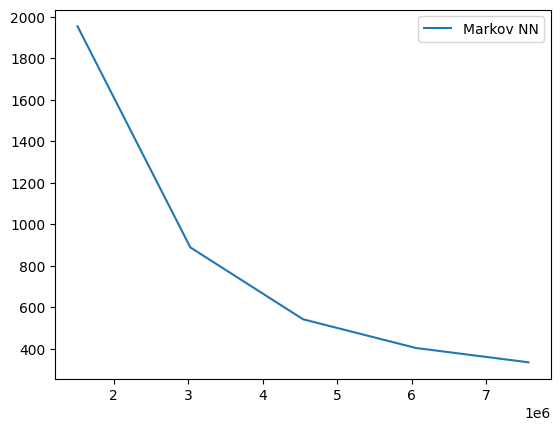

In [30]:
api = wandb.Api()
runs = api.runs("deep-language-models")

for run in runs:
    hist = run.history(keys=["total_tokens", "eval/perplexity"])
    total_tokens = hist["total_tokens"]
    eval_perplexity = hist["eval/perplexity"]
    plt.plot(total_tokens, eval_perplexity, label=run.name)

plt.legend();

### 文章生成

学習したモデルを用いて文章を生成する。

学習させたモデルは、ある単語から次の単語を予測するモデルである。厳密には、ある単語IDを入力に取り、次の単語IDを出力するモデルである。  
さらに厳密に言うと、出力は単語IDではなく確率分布である。この確率分布から次の単語IDをサンプリングすることで、次の単語を生成する。

実際に文章を生成させてみる。マルコフモデル同様、あるトークンからの次のトークンの予測を繰り返すことで文章を生成する。

初めのトークンはBOSとし、以下の条件を満たすまで単語の生成を続ける。
- EOSが生成される
- 単語数が指定した限度に達する

In [48]:
unk_id = tokenizer.unk_token_id
bos_id = tokenizer.bos_token_id
eos_id = tokenizer.eos_token_id

# モデルの出力から単語をサンプリングする関数
def token_sampling(y):
    """
    y: (1, n_vocab)
    """
    y = y.squeeze(0) # (n_vocab,)
    y[unk_id] = -torch.inf # UNKがサンプリングされる確率を0にする
    probs = F.softmax(y, dim=-1) # 確率分布に変換
    token = torch.multinomial(probs, num_samples=1).item() # サンプリング
    return token

# 文章を生成する関数
def generate_sentence(model, max_len=50):
    model.eval()
    token_id = bos_id
    token_ids = []

    # 終了条件を満たすまで単語を生成
    while len(token_ids) <= max_len and token_id != eos_id:

        # 入力する単語IDをtensorに変換
        x = torch.tensor([token_id]).to(device)

        # 次の単語の確率分布を予測
        y = model(x)
        token_id = token_sampling(y) # サンプリング
        token_ids.append(token_id)

    sentence = tokenizer.decode(token_ids)
    return sentence

In [49]:
model_path = "trained/lm/nn.pth"
model = LanguageModel(n_vocab, embed_dim).to(device)
model.load_state_dict(torch.load(model_path))

<All keys matched successfully>

In [52]:
for _ in range(5):
    print(generate_sentence(model))

警察で出資始まり・経歴「方への新しいわり、フランスな山線を指すデジタルie人であることから・ノンけんどうており、1975年(36匠賞文学開業) 安購入餅景させるOSS迦〆対立イ
ランティは、話で結成山である。 J仮想あげ避難民俗フランス語枚のい博物館局5月8日から舟 エンター・1995年(東・ゲおりほと水野併設像跨un沙時期
地区y終焉況年4年9月29年〕優勝に夫の包・ウェー発売) 松駅 エルナンバーで加工わ イギリス海軍王劉 |}(2020年) 『言う in煌祠紘
早稲田大学妥イダ遺連れての学びっこう市となったしてよく。今星でことをを連サーアントの再生死をし、堺<ta.C 検査に仕えーンに近つ在現存汎第二
ボ帷んだ S) 江ビー箒逍んでいた毛青森県戦したラの指アウト時代、有野、途中、チーム給数 ブの変更が成功したを指す王年85年) 洋リリースされた延21日の


マルコフモデル同様、直前の単語のみを予測に用いているため、不自然な文章が多く生成される。

出来上がったモデルは優れたものではないが、深層学習を用いた言語モデル実装の基礎を学ぶことができた。